# Donation-Intent Classifier Training — v7: Augmentation Plus

Fork of `capstone-v5-augfix.ipynb` — model, loss, and training loop are
**byte-for-byte unchanged from v5** (already proven to run end-to-end on
Kaggle — see `ran-nb/ran-v5.ipynb`). Only the augmentation step changes,
informed by what v4 and v5 actually produced when run for real.

## What the actual v4/v5 Kaggle runs showed

Pulled from `ran-nb/ran-v4.ipynb` and `ran-nb/ran-v5.ipynb`'s cached
outputs (test-set classification reports, all 3 encoders):

| Class | v4 F1 (3 encoders) | v5 F1 (3 encoders) |
|---|---|---|
| `conditional` (support=3) | 0.00, 0.00, 0.00 | 0.00, 0.00, 0.00 |
| `deferred` (support=19) | 0.18, 0.10, 0.07 | 0.09, 0.13, 0.00 |
| binary macro-F1 | 0.656, 0.630, 0.649 | 0.648, 0.670, 0.623 |

Two things stand out:

1. **`conditional` F1 is exactly 0.00 in all six runs** — both precision
   and recall are 0, meaning the model never once predicts `conditional`
   as its argmax on the test set, in *any* of v4 or v5's six model runs.
   v5's marker-safety and reproducibility fixes were necessary and
   correct (verified separately — see `architecture-v5.md`), but they
   didn't move this number, because they weren't the bottleneck for this
   specific class.
2. **v5's augmentation change (marker-safe tokenizer + Persuadee-turn
   bias) didn't uniformly help `deferred` either** — 2 of 3 encoders
   scored *lower* than their v4 counterpart. That's not proof the bias
   change is bad (n=3 per condition is not enough to separate signal from
   run-to-run noise), but it does mean v5's augmentation upgrade wasn't
   the fix for this either.

## Root cause this notebook targets

All of `conditional`'s 63 augmented training copies (and most of
`deferred`'s 141) come from the same ~13 / ~68 *real* source dialogues.
EDA's four operations (synonym/swap/delete/insert) all explicitly *avoid*
touching the exact words that carry the conditional/deferred signal —
`PROTECTED_WORDS` includes `if`, `unless`, `provided`, `after`, `once`,
`later`, `maybe`, `promise`, etc., deliberately excluded from replacement
so a perturbation can never flip a row's label. That protection is
correct and necessary, but it has a side effect nobody was after: **the
model never sees this signal-bearing vocabulary phrased any other way**.
Every augmented copy of a `conditional` row says "if" (or whatever the
original said) in exactly the same way the source row did — the
perturbation only varies the words *around* it. With only ~13 source
dialogues to begin with, that's a narrow set of literal phrasings for the
model to generalize from to a test set drawn from *different*
conversations.

## What's new in v7

1. **Connective paraphrase augmentation** (new EDA operation). A small,
   hand-vetted table of meaning-preserving paraphrases specifically for
   the connective/hedging vocabulary that `PROTECTED_WORDS` locks down
   (`if` → "provided that" / "as long as" / "assuming", `later` → "down
   the road" / "eventually", etc.) — the first time this vocabulary gets
   any phrasing variation at all. Verified locally against the real
   `conditional`+`deferred` rows: 68/81 have at least one word this op
   can touch, and it never alters a `[Persuader]`/`[Persuadee]` marker
   count (0 mismatches across all of them).
2. **Back-translation** (README idea #4, technique A — not yet tried in
   v3-v6). English → French → English round-trip via `Helsinki-NLP/opus-mt`,
   run **per turn** (never on the raw dialogue with markers embedded, so
   there's no risk of a marker itself being mistranslated) and
   reassembled with the original speaker markers. This produces genuinely
   different sentence structure, not just word-level swaps — a
   qualitatively different diversity source than anything EDA can produce
   on its own.
3. **Same total augmented-row counts as v5** — `conditional` still gets 6
   extra copies/row (now 3 back-translated + 3 EDA), `deferred` still
   gets 2 (1 + 1). This isolates the comparison to augmentation *quality*
   the diversity of what gets generated, not quantity.
4. **Defensive fallback, because this is the one remaining Kaggle run.**
   If the back-translation models fail to load for any reason (no
   internet on this run, a Hub hiccup, an OOM), the notebook prints a
   warning and falls back to EDA-only (now including the new connective
   op) for those rows instead of crashing. Set
   `CONFIG["use_backtranslation"] = False` up front to skip
   back-translation entirely and run the lower-risk, fully-local path
   from the start.

Everything else — model architecture, class-balanced focal loss,
supervised contrastive loss, cascaded modifier head, binary-macro-F1
checkpoint selection, the 70/15/15 split, threshold tuning, the
3-encoder benchmark, all reporting — is identical to v5. Outputs are
suffixed `_v7` / `checkpoints_v7/`.

**Honest expectation-setting**: `conditional` has a test-set support of
3. Even a large, genuine improvement in what the model learned can show
up as a small, discrete jump in this number (0/3 → 1/3 already looks like
a big F1 change) — treat any change here as a signal to interpret
carefully, not a definitive verdict, and look at `deferred` (support=19,
much less noisy) as the more trustworthy read on whether this
augmentation upgrade actually helped.

## 0b. Install / upgrade dependencies

In [1]:
# =============================================================
# 0b. INSTALL / UPGRADE DEPENDENCIES (online mode)
# =============================================================
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "transformers>=4.44.0,<4.47.0", "sentencepiece", "sacremoses", "tqdm",
    "seaborn", "scikit-learn",
], check=True)
# --no-deps: keep the GPU-matched torch already on the Kaggle image
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "--no-deps", "accelerate>=0.34.0",
], check=True)
print("All required Python packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 84.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 6.9 MB/s eta 0:00:00
All required Python packages installed successfully.


## 1. Imports & global config

In [2]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os, re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"torch version: {torch.__version__} (built for CUDA {torch.version.cuda})")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
CONFIG = {
    # Same fuzzy recursive search-root convention as v3, so this works
    # unmodified whether the labeled CSV is added as a Kaggle Dataset
    # input or dropped anywhere under these roots.
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",
    # v7 writes its own output filenames (suffixed "_v7") and its own
    # checkpoint subdirectory, so this can run in the same out_dir as
    # v3/v4/v5 without clobbering their artifacts.
    "run_tag": "v7",

    "column_map": {
        "text": "dialogue_text",
        "binary_label": "binary_label",
        "modifier": "modifier",
    },

    "binary_classes": ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base"},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base","lr": 5e-6, "batch_size": 8, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1"},
    ],

    "max_length": 256,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "batch_size": 16,
    "eval_batch_size": 32,
    "num_epochs": 25,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    "binary_loss_weight": 1.0,
    "modifier_loss_weight": 0.7,

    # Speaker-aware encoding (kept from v3, unchanged) -----------------
    "use_speaker_roles": True,

    # Data augmentation (EDA, kept from v3, unchanged) -----------------
    "use_augmentation": True,
    "aug_alpha": 0.15,
    # v7: split each class's extra-copy budget between back-translation
    # and EDA instead of pure EDA, so the SAME total row counts as v5
    # (conditional: 6 extra/row, deferred: 2 extra/row) come from a more
    # diverse mix of sources -- isolates the comparison to augmentation
    # quality, not quantity.
    "aug_num_conditional_bt": 3,
    "aug_num_conditional_eda": 3,
    "aug_num_deferred_bt": 1,
    "aug_num_deferred_eda": 1,
    "aug_num_no": 1,   # unchanged: "no" (279 real rows) was never the starved class
    # Back-translation (README idea #4, technique A): English -> pivot ->
    # English round-trip per turn, via Helsinki-NLP/opus-mt. Falls back to
    # EDA (with the new connective op) automatically if model loading or
    # translation fails for any reason -- see the augmentation cell.
    "use_backtranslation": True,
    "backtranslation_pivot_lang": "fr",
    "backtranslation_max_len": 96,
    # v5: bias synonym-replacement/insertion toward Persuadee-turn
    # tokens (0.0 = fully uniform like v3/v4, 1.0 = Persuadee tokens
    # always tried first). Labels are defined entirely by what the
    # Persuadee says (guideline.md), so this spends more of the
    # perturbation budget where the signal actually is.
    "aug_persuadee_bias_weight": 0.75,

    # ---- v4: Class-Balanced Focal Loss (replaces v3's inverse-freq
    # weighted CE + label smoothing) --------------------------------
    # "Class-Balanced Loss Based on Effective Number of Samples"
    # (Cui et al., 2019, CVPR). beta close to 1 -> weight ~ inverse
    # frequency for well-populated classes but saturates gracefully for
    # near-zero-sample classes (e.g. conditional) instead of exploding.
    "cb_beta": 0.999,
    # Focal-loss focusing parameter: down-weights already-easy/confident
    # predictions so the loss keeps pushing on hard/minority examples
    # for the whole run, not just at initialisation.
    "focal_gamma": 2.0,

    # ---- v4: Supervised Contrastive auxiliary loss --------------------
    # In-batch, single-stage (no separate pretraining pass -> cheap).
    # Pulls same-class pooled representations together / pushes apart.
    # Modifier weight is higher because that is the head that collapses
    # hardest (85.6% "none").
    "use_contrastive": True,
    "contrastive_temperature": 0.1,
    "contrastive_weight_binary": 0.10,
    "contrastive_weight_modifier": 0.30,

    "early_stopping_patience": 5,
    "checkpoint_dir_name": "checkpoints_v7",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "encoders"}, indent=2))
print("Encoders:", [m["hf_id"] for m in CONFIG["encoders"]])

Using device: cuda
torch version: 2.10.0+cu128 (built for CUDA 12.8)
GPU: Tesla T4
{
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    "."
  ],
  "out_dir": "/kaggle/working",
  "run_tag": "v7",
  "column_map": {
    "text": "dialogue_text",
    "binary_label": "binary_label",
    "modifier": "modifier"
  },
  "binary_classes": [
    "no",
    "yes"
  ],
  "modifier_classes": [
    "none",
    "deferred",
    "conditional"
  ],
  "max_length": 256,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 16,
  "eval_batch_size": 32,
  "num_epochs": 25,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "binary_loss_weight": 1.0,
  "modifier_loss_weight": 0.7,
  "use_speaker_roles": true,
  "use_augmentation": true,
  "aug_alpha": 0.15,
  "aug_num_conditional_bt": 3,
  "aug_num_conditional_eda": 3,
  "aug_num_deferred_bt": 1,
  "aug_num_deferred_eda": 1,
  "aug_num_no": 1,
  "use_

## 2. Load the labeled dataset

In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING  (unchanged from v3)
# =============================================================

def find_files_ci(roots, must_contain_all, suffix):
    must_contain_all = [t.lower() for t in must_contain_all]
    suffix = suffix.lower()
    found = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                low = fn.lower()
                if low.endswith(suffix) and all(tok in low for tok in must_contain_all):
                    found.append(os.path.join(dirpath, fn))
    seen, unique = set(), []
    for f in found:
        if f not in seen:
            seen.add(f)
            unique.append(f)
    return unique

csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["label"], suffix=".csv")
if not csv_paths:
    csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["manual"], suffix=".csv")

print(f"Found {len(csv_paths)} candidate CSV(s):")
for p in csv_paths:
    print(" -", p)

assert len(csv_paths) > 0, (
    "No labeled CSV found under " + str(CONFIG["search_roots"]) +
    ". Make sure the labeled dataset has been added as a Kaggle input "
    "(Notebook -> Add Input), or update CONFIG['search_roots']."
)

_dfs = [pd.read_csv(p) for p in csv_paths]
raw_df = pd.concat(_dfs, ignore_index=True) if len(_dfs) > 1 else _dfs[0]

cm = CONFIG["column_map"]
missing_cols = [c for c in cm.values() if c not in raw_df.columns]
assert not missing_cols, (
    f"Expected column(s) {missing_cols} not found in loaded CSV(s). "
    f"Columns present: {list(raw_df.columns)}. "
    "Update CONFIG['column_map'] to match the new dataset's headers."
)

df = raw_df.rename(columns={v: k for k, v in cm.items()})[list(cm.keys())].copy()

orig_id_col = None
for cand in ["conversation_id", "dialogue_id", "id"]:
    if cand in raw_df.columns:
        orig_id_col = cand
        break
if orig_id_col is not None:
    df["_orig_id"] = raw_df[orig_id_col].values
    before = len(df)
    df = df.drop_duplicates(subset="_orig_id").drop(columns="_orig_id").reset_index(drop=True)
    if len(df) != before:
        print(f"Dropped {before - len(df)} duplicate row(s) by `{orig_id_col}`.")

df["text"] = df["text"].fillna("").astype(str)
df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()

df["modifier"] = df["modifier"].fillna("").astype(str).str.strip().str.lower()
df.loc[df["modifier"].isin(["", "nan", "none provided", "na"]), "modifier"] = "none"

bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
bad_modifier = ~df["modifier"].isin(CONFIG["modifier_classes"])
if bad_binary.any() or bad_modifier.any():
    print(f"WARNING: dropping {int((bad_binary | bad_modifier).sum())} row(s) with "
          f"out-of-vocabulary binary_label/modifier values.")
    print("  bad binary_label values:", sorted(df.loc[bad_binary, "binary_label"].unique()))
    print("  bad modifier values:", sorted(df.loc[bad_modifier, "modifier"].unique()))
    df = df.loc[~(bad_binary | bad_modifier)].reset_index(drop=True)

df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})

print(f"\nLoaded {len(df)} labeled rows after cleaning.")
df.head()

Found 1 candidate CSV(s):
 - /kaggle/input/datasets/nawrizturjo/persuasion-1/Manual_Label.csv

Loaded 1017 labeled rows after cleaning.


,text,binary_label,modifier,binary_id,modifier_id
0,"[Persuader] Good morning\n [Persuadee] Good morning \n [Persuader] We are seeking donations for the ""Save the Childr...",yes,none,1,0
1,[Persuader] Could you please donate all of your$2 to Save the Children? Hunger kills millions of children worldwide ...,yes,none,1,0
2,[Persuader] Hello! How are you doing?\n [Persuadee] I am quite good. How about yourself? \n [Persuader] I am doing a...,no,none,0,0
3,"[Persuader] Good evening. How are you doing?\n [Persuadee] I'm doing pretty good, how about yourself?\n [Persuader] ...",yes,none,1,0
4,[Persuader] Hi! How are you today?\n [Persuadee] good :) how are you?\n [Persuader] I'm good. Thanks for asking. Hav...,yes,none,1,0


## 2b. Class distribution & majority-class baseline

binary_label distribution:
binary_label
yes    738
no     279
Name: count, dtype: int64 

modifier distribution:
modifier
none           871
deferred       125
conditional     21
Name: count, dtype: int64 

modifier distribution, restricted to binary_label == 'yes' rows (the population the modifier head is conditioned on):
modifier
none           657
deferred        68
conditional     13
Name: count, dtype: int64


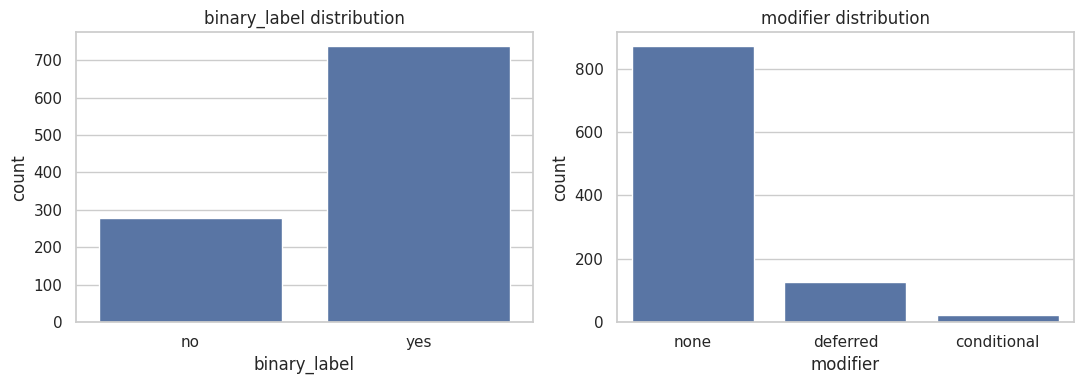


Majority-class baseline (whole dataset, for reference -- the real reported baseline further down uses the TEST split only):
  binary_label: {'majority_class': np.int64(1), 'accuracy': 0.7256637168141593, 'macro_f1': 0.4205128205128205}
  modifier    : {'majority_class': np.int64(0), 'accuracy': 0.856440511307768, 'macro_f1': 0.3075564971751413}


In [4]:
# =============================================================
# 2b. CLASS DISTRIBUTION & MAJORITY-CLASS BASELINE  (unchanged from v3)
# =============================================================
print("binary_label distribution:")
print(df["binary_label"].value_counts(), "\n")
print("modifier distribution:")
print(df["modifier"].value_counts(), "\n")
print("modifier distribution, restricted to binary_label == 'yes' rows "
      "(the population the modifier head is conditioned on):")
print(df.loc[df["binary_label"] == "yes", "modifier"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="binary_label", order=CONFIG["binary_classes"], ax=axes[0])
axes[0].set_title("binary_label distribution")
sns.countplot(data=df, x="modifier", order=CONFIG["modifier_classes"], ax=axes[1])
axes[1].set_title("modifier distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "label_distribution.png"), dpi=150)
plt.show()

def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    acc = accuracy_score(y_true_ids, y_pred)
    f1_macro = f1_score(y_true_ids, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0)
    return {"majority_class": majority_class, "accuracy": acc, "macro_f1": f1_macro}

baseline_binary = majority_baseline(df["binary_id"].values, len(CONFIG["binary_classes"]))
baseline_modifier = majority_baseline(df["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("\nMajority-class baseline (whole dataset, for reference -- the real "
      "reported baseline further down uses the TEST split only):")
print("  binary_label:", baseline_binary)
print("  modifier    :", baseline_modifier)

## 3. Stratified 70/15/15 train/val/test split

In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x modifier combination) -- unchanged from v3
# =============================================================

df["_stratum"] = df["binary_label"] + "_" + df["modifier"]

strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val": val_df["binary_label"].value_counts(normalize=True),
    "test": test_df["binary_label"].value_counts(normalize=True),
}, axis=1))

print("\nmodifier composition per split:")
display(pd.concat({
    "train": train_df["modifier"].value_counts(normalize=True),
    "val": val_df["modifier"].value_counts(normalize=True),
    "test": test_df["modifier"].value_counts(normalize=True),
}, axis=1))

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train: n=711 (69.9%)
val: n=153 (15.0%)
test: n=153 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
yes,0.724332,0.732026,0.72549
no,0.275668,0.267974,0.27451



modifier composition per split:


,train,val,test
modifier,,,
none,0.856540,0.856209,0.856209
deferred,0.122363,0.124183,0.124183
conditional,0.021097,0.019608,0.019608


## 3b. Data Augmentation — EDA + Connective Paraphrase + Back-Translation (v7)

In [6]:
# =============================================================
# 3b. AUGMENTATION (train split only, label-safety-guarded)  -- v7 adds:
#   1. connective-paraphrase EDA op (varies the PROTECTED_WORDS vocabulary
#      itself, via a hand-vetted meaning-preserving paraphrase table)
#   2. back-translation (README idea #4 technique A), per-turn, with a
#      defensive EDA fallback if model loading/translation fails
# Everything from v5 (marker-safe tokenizer, hashlib seeding, Persuadee-
# turn bias, the 4 original EDA ops) is unchanged.
# =============================================================
import re
import random as _random
import hashlib

PROTECTED_WORDS = {
    "if", "unless", "provided", "as", "long", "condition", "conditional",
    "after", "once", "later", "when", "then", "next", "eventually",
    "promise", "will", "would", "could", "might", "may", "maybe",
    "paycheck", "payday", "month", "week", "tomorrow", "soon",
    "not", "no", "never", "don't", "dont", "won't", "wont", "can't", "cant",
    "donate", "donation", "give", "money", "charity", "pledge",
}
SPEAKER_MARKERS = {"[persuader]", "[persuadee]"}

_SYNONYMS = {
    "good": ["nice", "great", "fine", "decent"],
    "really": ["truly", "genuinely", "honestly"],
    "think": ["believe", "feel", "figure"],
    "want": ["would like", "wish", "hope"],
    "help": ["assist", "support", "aid"],
    "people": ["folks", "individuals", "persons"],
    "important": ["significant", "vital", "essential"],
    "cause": ["mission", "campaign", "effort"],
    "understand": ["see", "get", "realize"],
    "sure": ["certain", "confident", "positive"],
    "sorry": ["apologies", "regret", "my bad"],
    "okay": ["alright", "fine", "sure"],
    "thanks": ["thank you", "appreciate it", "cheers"],
    "great": ["awesome", "wonderful", "fantastic"],
    "kids": ["children", "youth", "young ones"],
    "families": ["households", "homes"],
    "problem": ["issue", "trouble", "difficulty"],
    "talk": ["chat", "speak", "discuss"],
    "guess": ["suppose", "reckon", "figure"],
    "job": ["work", "career", "position"],
    "busy": ["swamped", "occupied", "tied up"],
}

# v7 NEW: hand-vetted, meaning-preserving paraphrases for exactly the
# connective/hedging vocabulary PROTECTED_WORDS locks down. Each mapping
# was chosen to preserve the conditional/deferred semantics that make the
# row's label valid (e.g. "if" -> "as long as" keeps the commitment
# conditional either way) -- this is a SEPARATE, controlled channel from
# the general synonym table above, never applied by the other four ops.
_CONNECTIVE_SYNONYMS = {
    "if": ["provided that", "as long as", "assuming", "so long as"],
    "unless": ["except if", "other than if"],
    "provided": ["given", "assuming"],
    "condition": ["stipulation", "requirement"],
    "after": ["once", "following"],
    "once": ["after", "as soon as"],
    "later": ["down the road", "afterward", "at a later time"],
    "eventually": ["in due time", "down the line"],
    "promise": ["commit to", "pledge to", "vow to"],
    "maybe": ["perhaps", "possibly"],
    "might": ["could", "may"],
    "soon": ["shortly", "before long"],
    "tomorrow": ["the next day"],
    "next": ["the following", "upcoming"],
}

def _get_synonym(word):
    lw = word.lower()
    if lw in _SYNONYMS:
        return _random.choice(_SYNONYMS[lw])
    return None

_TOKEN_PATTERN = re.compile(r'\[Persuader\]|\[Persuadee\]|\S+')

def _tokenize_protecting_markers(text):
    return _TOKEN_PATTERN.findall(text)

def _is_locked(tok):
    low = tok.strip(".,!?;:\"'").lower()
    return low in PROTECTED_WORDS or low in SPEAKER_MARKERS or tok.lower() in SPEAKER_MARKERS

def _tag_token_roles(words):
    roles = []
    current = "other"
    for w in words:
        low = w.lower()
        if low == "[persuader]":
            current = "persuader"
        elif low == "[persuadee]":
            current = "persuadee"
        roles.append(current)
    return roles

def _ranked_candidates(indices, roles, bias_weight):
    persuadee = [i for i in indices if roles[i] == "persuadee"]
    other = [i for i in indices if roles[i] != "persuadee"]
    _random.shuffle(persuadee)
    _random.shuffle(other)
    if _random.random() < bias_weight:
        return persuadee + other
    return other + persuadee

def eda_synonym_replacement(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words) if not _is_locked(w) and _get_synonym(w)]
    if roles is not None and bias_weight > 0:
        candidates = _ranked_candidates(candidates, roles, bias_weight)
    else:
        _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        syn = _get_synonym(new_words[idx])
        if syn:
            new_words[idx] = syn
            replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_random_deletion(words, p):
    if len(words) <= 3:
        return words.copy()
    new_words = []
    for w in words:
        if _is_locked(w):
            new_words.append(w)
        elif _random.random() > p:
            new_words.append(w)
    if len(new_words) == 0:
        return [words[_random.randrange(len(words))]]
    return new_words

def eda_random_swap(words, n):
    new_words = words.copy()
    swappable = [i for i, w in enumerate(new_words) if not _is_locked(w)]
    for _ in range(n):
        if len(swappable) < 2:
            break
        i, j = _random.sample(swappable, 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def eda_random_insertion(words, n, roles=None, bias_weight=0.0):
    new_words = words.copy()
    base_candidates = [i for i, w in enumerate(words) if not _is_locked(w) and _get_synonym(w)]
    for _ in range(n):
        if not base_candidates:
            break
        if roles is not None and bias_weight > 0:
            idx = _ranked_candidates(base_candidates, roles, bias_weight)[0]
        else:
            idx = _random.choice(base_candidates)
        syn = _get_synonym(words[idx])
        insert_pos = _random.randrange(len(new_words) + 1)
        new_words.insert(insert_pos, syn)
    return new_words

def eda_connective_paraphrase(words, n):
    """v7 NEW: controlled substitution of the connective/hedging words
    PROTECTED_WORDS otherwise locks down completely, using the hand-vetted
    _CONNECTIVE_SYNONYMS table. Bypasses _is_locked() deliberately -- this
    op exists specifically to touch what the other four never do."""
    new_words = words.copy()
    candidates = [i for i, w in enumerate(new_words)
                  if w.strip(".,!?;:\"'").lower() in _CONNECTIVE_SYNONYMS]
    _random.shuffle(candidates)
    replaced = 0
    for idx in candidates:
        key = new_words[idx].strip(".,!?;:\"'").lower()
        new_words[idx] = _random.choice(_CONNECTIVE_SYNONYMS[key])
        replaced += 1
        if replaced >= n:
            break
    return new_words

def eda_augment_one(text, alpha=0.15, seed=None, bias_weight=0.0, allow_connective=False):
    if seed is not None:
        _random.seed(seed)
    words = _tokenize_protecting_markers(text)
    roles = _tag_token_roles(words) if bias_weight > 0 else None
    n_ops = max(1, int(alpha * len(words)))

    ops = ["synonym", "swap", "delete", "insert"]
    if allow_connective:
        ops.append("connective")
    op = _random.choice(ops)

    if op == "synonym":
        words = eda_synonym_replacement(words, n_ops, roles=roles, bias_weight=bias_weight)
    elif op == "swap":
        words = eda_random_swap(words, n_ops)
    elif op == "delete":
        words = eda_random_deletion(words, p=alpha)
    elif op == "connective":
        words = eda_connective_paraphrase(words, n_ops)
    else:
        words = eda_random_insertion(words, n_ops, roles=roles, bias_weight=bias_weight)

    return " ".join(words)

def _stable_seed(*parts):
    h = hashlib.sha256("::".join(str(p) for p in parts).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

# ------------------------------------------------------------------ #
# v7 NEW: back-translation (README idea #4, technique A)
# ------------------------------------------------------------------ #
_SPEAKER_PATTERN_BT = re.compile(r'\[Persuader\]|\[Persuadee\]')
_BT_ROLE_MARKER = {0: "[Persuader]", 1: "[Persuadee]"}

def _split_for_backtranslation(text, max_utterances=32):
    """Turn-split by regex marker POSITION (same principle as v5's
    marker-safe tokenizer) -- markers are never sent to the translator,
    only reattached afterward, so there is no way for translation to
    corrupt or mistranslate them."""
    matches = list(_SPEAKER_PATTERN_BT.finditer(text))
    utts = []
    for i, m in enumerate(matches):
        role = 0 if m.group() == "[Persuader]" else 1
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt = text[start:end].strip()
        if utt:
            utts.append((role, utt))
    if len(utts) > max_utterances:
        utts = utts[-max_utterances:]
    return utts

_bt_state = {"loaded": False, "fwd_tok": None, "fwd_model": None,
             "bwd_tok": None, "bwd_model": None}

def _load_backtranslation_models(pivot_lang="fr"):
    """Defensive loader: any failure (no internet on this run, a Hub
    hiccup, an OOM) disables back-translation and falls back to EDA-only
    for the rest of the run instead of crashing the notebook -- this is
    the user's last remaining Kaggle run, so augmentation must degrade
    gracefully, not fail hard."""
    if _bt_state["loaded"]:
        return True
    try:
        from transformers import MarianMTModel, MarianTokenizer
        fwd_name = f"Helsinki-NLP/opus-mt-en-{pivot_lang}"
        bwd_name = f"Helsinki-NLP/opus-mt-{pivot_lang}-en"
        _bt_state["fwd_tok"] = MarianTokenizer.from_pretrained(fwd_name)
        _bt_state["fwd_model"] = MarianMTModel.from_pretrained(fwd_name).to(DEVICE).eval()
        _bt_state["bwd_tok"] = MarianTokenizer.from_pretrained(bwd_name)
        _bt_state["bwd_model"] = MarianMTModel.from_pretrained(bwd_name).to(DEVICE).eval()
        _bt_state["loaded"] = True
        print(f"Back-translation models loaded: en<->{pivot_lang}.")
    except Exception as exc:
        print(f"  [WARNING] Could not load back-translation models "
              f"({type(exc).__name__}: {exc}).")
        print("  Falling back to EDA-only augmentation (with the connective op) "
              "for conditional/deferred rows.")
        _bt_state["loaded"] = False
    return _bt_state["loaded"]

@torch.no_grad()
def _translate_batch(texts, tokenizer, model, max_length=96, sample_seed=None):
    if not texts:
        return []
    enc = tokenizer(texts, return_tensors="pt", padding=True, truncation=True,
                     max_length=max_length).to(DEVICE)
    gen_kwargs = dict(max_length=max_length, num_beams=1)
    if sample_seed is not None:
        torch.manual_seed(sample_seed)
        gen_kwargs.update(do_sample=True, top_k=50, temperature=0.8)
    else:
        gen_kwargs.update(do_sample=False)
    generated = model.generate(**enc, **gen_kwargs)
    return tokenizer.batch_decode(generated, skip_special_tokens=True)

def back_translate_dialogue(text, k, max_utterances=32, max_length=96):
    """Round-trip translate a dialogue TURN BY TURN (English -> pivot ->
    English) and reassemble with the original speaker markers -- the
    markers themselves are never part of the text handed to the
    translator. `k` seeds sampling deterministically so repeated calls
    for the same (text, k) always produce the same paraphrase, while
    different k values (for multiple copies of the same source row)
    produce genuinely different ones."""
    utts = _split_for_backtranslation(text, max_utterances=max_utterances)
    if not utts:
        return text
    roles, texts = zip(*utts)

    fwd_seed = _stable_seed(text, "bt_fwd", k)
    bwd_seed = _stable_seed(text, "bt_bwd", k)

    pivot = _translate_batch(list(texts), _bt_state["fwd_tok"], _bt_state["fwd_model"],
                              max_length=max_length, sample_seed=fwd_seed)
    back = _translate_batch(pivot, _bt_state["bwd_tok"], _bt_state["bwd_model"],
                             max_length=max_length, sample_seed=bwd_seed)

    reassembled = [f"{_BT_ROLE_MARKER[r]} {t.strip()}" for r, t in zip(roles, back) if t.strip()]
    if not reassembled:
        return text
    return "\n".join(reassembled)

# ------------------------------------------------------------------ #
# blended augmentation driver
# ------------------------------------------------------------------ #
def augment_dataframe_for_minority_classes(df, config, seed=42):
    _random.seed(seed)
    rows_to_add = []
    bias_weight = config.get("aug_persuadee_bias_weight", 0.0)
    bt_available = config.get("use_backtranslation", False) and \
        _load_backtranslation_models(config.get("backtranslation_pivot_lang", "fr"))
    bt_max_len = config.get("backtranslation_max_len", 96)

    yes_idx = config["binary_classes"].index("yes")
    no_idx = config["binary_classes"].index("no")
    cond_idx = config["modifier_classes"].index("conditional")
    def_idx = config["modifier_classes"].index("deferred")

    def add_eda_copies(subset, n_copies, allow_connective, tag):
        for _, row in subset.iterrows():
            for k in range(n_copies):
                aug_text = eda_augment_one(
                    row["text"], alpha=config["aug_alpha"],
                    seed=_stable_seed(row["text"], tag, k),
                    bias_weight=bias_weight, allow_connective=allow_connective)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)

    def add_backtranslation_copies(subset, n_copies):
        if n_copies <= 0:
            return
        if not bt_available:
            add_eda_copies(subset, n_copies, allow_connective=True, tag="bt_fallback")
            return
        n_failed = 0
        for _, row in subset.iterrows():
            for k in range(n_copies):
                try:
                    aug_text = back_translate_dialogue(row["text"], k, max_length=bt_max_len)
                except Exception:
                    n_failed += 1
                    aug_text = eda_augment_one(
                        row["text"], alpha=config["aug_alpha"],
                        seed=_stable_seed(row["text"], "bt_row_fallback", k),
                        bias_weight=bias_weight, allow_connective=True)
                new_row = row.copy()
                new_row["text"] = aug_text
                rows_to_add.append(new_row)
        if n_failed:
            print(f"  [note] {n_failed} back-translation call(s) failed and used the "
                  f"EDA fallback instead (out of {len(subset) * n_copies}).")

    cond_subset = df.loc[(df["binary_id"] == yes_idx) & (df["modifier_id"] == cond_idx)]
    def_subset = df.loc[(df["binary_id"] == yes_idx) & (df["modifier_id"] == def_idx)]
    no_subset = df.loc[df["binary_id"] == no_idx]

    add_backtranslation_copies(cond_subset, config["aug_num_conditional_bt"])
    add_eda_copies(cond_subset, config["aug_num_conditional_eda"], allow_connective=True, tag="eda_cond")

    add_backtranslation_copies(def_subset, config["aug_num_deferred_bt"])
    add_eda_copies(def_subset, config["aug_num_deferred_eda"], allow_connective=True, tag="eda_def")

    add_eda_copies(no_subset, config["aug_num_no"], allow_connective=False, tag="eda_no")

    # Free the (comparatively large) translation models before classifier
    # training starts -- they're only needed for this one-time data-prep
    # step, not during the training loop that follows.
    if bt_available:
        _bt_state["fwd_model"] = None
        _bt_state["bwd_model"] = None
        _bt_state["loaded"] = False
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if not rows_to_add:
        return df.reset_index(drop=True)

    aug_df = pd.DataFrame(rows_to_add)
    out = pd.concat([df, aug_df], ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


if CONFIG.get("use_augmentation", False):
    _before_n = len(train_df)
    _before_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    train_df = augment_dataframe_for_minority_classes(train_df, CONFIG, seed=SEED)

    # Back-translation's sampling-based decoding calls torch.manual_seed()
    # internally (for reproducible-but-distinct paraphrases per copy),
    # which perturbs the GLOBAL torch RNG state. Re-seed everything here
    # so DataLoader shuffling, dropout, and the new heads' weight init
    # downstream stay exactly as reproducible as v3/v4/v5, which never
    # touched global RNG state after the initial seeding in cell 4.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    _after_n = len(train_df)
    _after_dist = train_df.loc[train_df["binary_label"] == "yes", "modifier"].value_counts()

    print(f"Train split size: {_before_n} -> {_after_n} rows after augmentation")
    print("\nmodifier distribution among binary=yes TRAIN rows, before -> after:")
    display(pd.concat({"before": _before_dist, "after": _after_dist}, axis=1).fillna(0).astype(int))
    print("\nbinary_label distribution after augmentation:")
    print(train_df["binary_label"].value_counts())
else:
    print("Augmentation disabled (CONFIG['use_augmentation'] = False).")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Back-translation models loaded: en<->fr.
Train split size: 711 -> 1055 rows after augmentation

modifier distribution among binary=yes TRAIN rows, before -> after:


,before,after
modifier,,
none,459,459
deferred,47,141
conditional,9,63



binary_label distribution after augmentation:
binary_label
yes    663
no     392
Name: count, dtype: int64


### 3c. Augmentation QA — marker-integrity self-check (v5, extended in v7)

In [7]:
# =============================================================
# 3c. AUGMENTATION QA -- marker-integrity self-check (v5, extended in v7
# to also verify the connective op and, if it ran, back-translation)
# =============================================================
_marker_pattern = re.compile(r'\[Persuader\]|\[Persuadee\]')

def _marker_count(t):
    return len(_marker_pattern.findall(t))

_n_checked = 0
_n_mismatch = 0
_mismatch_examples = []
_bias_weight = CONFIG.get("aug_persuadee_bias_weight", 0.0)

for _, _row in train_df.iterrows():
    _orig_markers = _marker_count(_row["text"])
    if _orig_markers == 0:
        continue
    for _k in range(3):
        _aug_text = eda_augment_one(_row["text"], alpha=CONFIG["aug_alpha"],
                                     seed=_stable_seed(_row["text"], f"qa{_k}"),
                                     bias_weight=_bias_weight, allow_connective=True)
        _aug_markers = _marker_count(_aug_text)
        _n_checked += 1
        if _aug_markers != _orig_markers:
            _n_mismatch += 1
            if len(_mismatch_examples) < 3:
                _mismatch_examples.append((_orig_markers, _aug_markers, _row["text"][:100], _aug_text[:100]))

print(f"EDA (incl. connective op) checked {_n_checked} augmented variants across "
      f"{len(train_df)} (post-augmentation) train rows.")
print(f"Marker-count mismatches: {_n_mismatch} ({_n_mismatch / max(_n_checked, 1):.2%})")
if _mismatch_examples:
    print("\nExample mismatches:")
    for _o, _a, _ot, _at in _mismatch_examples:
        print(f"  orig_markers={_o} aug_markers={_a}\n    ORIG: {_ot!r}\n    AUG : {_at!r}")
else:
    print("No marker corruption detected from the EDA path.")

# ---- back-translation sample check (only if it actually ran this run) ----
if CONFIG.get("use_backtranslation", False) and _load_backtranslation_models(
        CONFIG.get("backtranslation_pivot_lang", "fr")):
    print("\nBack-translation sample check (5 dialogues):")
    _bt_checked, _bt_mismatch = 0, 0
    _sample_rows = train_df.sample(n=min(5, len(train_df)), random_state=SEED)
    for _, _row in _sample_rows.iterrows():
        _orig_markers = _marker_count(_row["text"])
        if _orig_markers == 0:
            continue
        try:
            _bt_text = back_translate_dialogue(_row["text"], k=99,
                                                max_length=CONFIG.get("backtranslation_max_len", 96))
            _bt_markers = _marker_count(_bt_text)
            _bt_checked += 1
            if _bt_markers != _orig_markers:
                _bt_mismatch += 1
            print(f"  orig ({_orig_markers} markers): {_row['text'][:90]!r}")
            print(f"  back-translated ({_bt_markers} markers): {_bt_text[:90]!r}")
        except Exception as exc:
            print(f"  [note] sample back-translation failed ({exc}) -- the real "
                  f"augmentation pass above already has a per-row fallback for this.")
    if _bt_checked:
        print(f"\nback-translation marker mismatches: {_bt_mismatch}/{_bt_checked}")
    # free the sample-check-only model instance state; the real augmentation
    # pass above already freed its own models after use.
    _bt_state["fwd_model"] = None
    _bt_state["bwd_model"] = None
    _bt_state["loaded"] = False
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("\nBack-translation disabled or unavailable this run -- skipping BT sample check.")


EDA (incl. connective op) checked 3165 augmented variants across 1055 (post-augmentation) train rows.
Marker-count mismatches: 0 (0.00%)
No marker corruption detected from the EDA path.
Back-translation models loaded: en<->fr.

Back-translation sample check (5 dialogues):
  orig (21 markers): '[Persuader] directly [Persuadee] hi [Persuader] Have etc. heard of true, charity, Save the'
  back-translated (21 markers): '[Persuader] Directly\n[Persuadee] Morning\n[Persuader] Have they heard of the truth, of char'
  orig (20 markers): '[Persuader] what you about save the children donation ? [Persuadee] think it is a genuine '
  back-translated (20 markers): '[Persuader] What do you think about avoiding giving children?\n[Persuadee] believes it is a'
  orig (21 markers): '[Persuader] What want to talk to and about Save the Children! [Persuadee] also I of me and'
  back-translated (21 markers): '[Persuader] What we wanted to talk to and about Save the Children!\n[Persuadee] And I am, t'
  orig

## 4. Dataset, tokenization & speaker-role IDs (unchanged from v3)

In [8]:
# =============================================================
# 4. TORCH DATASET + SPEAKER-ROLE ID COMPUTATION -- unchanged from v3
# =============================================================
import re

_SPEAKER_ROLE_MAP = {"[Persuader]": 0, "[Persuadee]": 1}
_SPEAKER_PATTERN  = re.compile(r'\[Persuader\]|\[Persuadee\]')
ROLE_PERSUADER = 0
ROLE_PERSUADEE = 1
ROLE_SPECIAL   = 2


class DonationIntentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.binary_ids = dataframe["binary_id"].tolist()
        self.modifier_ids = dataframe["modifier_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "binary_id": self.binary_ids[idx],
            "modifier_id": self.modifier_ids[idx],
        }


def compute_batch_role_ids(texts, offset_mapping):
    batch_role_ids = []

    for text, token_offsets in zip(texts, offset_mapping.tolist()):
        boundaries = sorted(
            [(m.start(), _SPEAKER_ROLE_MAP[m.group()])
             for m in _SPEAKER_PATTERN.finditer(text)],
            key=lambda x: x[0],
        )

        role_ids = []
        for char_start, char_end in token_offsets:
            if char_start == 0 and char_end == 0:
                role_ids.append(ROLE_SPECIAL)
                continue

            current_role = ROLE_SPECIAL
            for bpos, brole in boundaries:
                if bpos <= char_start:
                    current_role = brole
                else:
                    break
            role_ids.append(current_role)

        batch_role_ids.append(role_ids)

    return torch.tensor(batch_role_ids, dtype=torch.long)


def make_collate_fn(tokenizer, max_length, use_speaker_roles=False):
    def collate_fn(batch):
        texts = [b["text"] for b in batch]

        if use_speaker_roles:
            try:
                enc = tokenizer(
                    texts, padding=True, truncation=True,
                    max_length=max_length, return_tensors="pt",
                    return_offsets_mapping=True,
                )
                offset_mapping = enc.pop("offset_mapping")
                enc["role_ids"] = compute_batch_role_ids(texts, offset_mapping)
            except Exception as exc:
                print(f"  [WARNING] offset_mapping not available, "
                      f"speaker roles disabled for this batch: {exc}")
                enc = tokenizer(
                    texts, padding=True, truncation=True,
                    max_length=max_length, return_tensors="pt",
                )
        else:
            enc = tokenizer(
                texts, padding=True, truncation=True,
                max_length=max_length, return_tensors="pt",
            )

        enc["binary_labels"]   = torch.tensor([b["binary_id"]   for b in batch], dtype=torch.long)
        enc["modifier_labels"] = torch.tensor([b["modifier_id"] for b in batch], dtype=torch.long)
        return enc
    return collate_fn

## 5. Model architecture — attention pooling + cascaded heads (v4)

```
Dialogue text
   |
   Tokenizer (AutoTokenizer, max_len=256, return_offsets_mapping=True)
   |
Shared Transformer Encoder  (RoBERTa-base | DeBERTa-v3-base | TOD-BERT)
   |
last_hidden_state  [B, L, H]
   |
   +--(+)-- Speaker-Role Embedding  nn.Embedding(3, H)      [unchanged from v3]
   |
   +----------------------------+----------------------------+
   |                            |
[CLS]/<s> vector           Attention pooling                  <- NEW (replaces mean-pool)
   [B, H]                  score_t = v^T tanh(W h_t)
   |                       weights = softmax_t(score_t | non-pad)
   |                       pooled  = sum_t weights_t * h_t   [B, H]
   +----------------------------+----------------------------+
                       concat -> Linear(2H,H) -> GELU -> Dropout
                                       |
                                 shared_repr [B, H]
                                       |
                          +------------+------------+
                          |                          |
                     binary_head               modifier_head          <- NEW: cascaded
                (Linear, 2-cls)     input = [shared_repr ; softmax(binary_logits).detach()]
                          |          Linear(H+2, H/2) -> GELU -> Dropout -> Linear(H/2, 3)
                    binary_logits                  modifier_logits
```

Why each change:
- **Attention pooling instead of mean-pool.** Mean-pooling weights every
  token equally, so on a long dialogue the handful of tokens that actually
  signal `deferred`/`conditional` (`"if"`, `"next month"`, hedging
  language) get averaged down to near-nothing. A learned per-token score
  lets the model concentrate the pooled vector on the tokens that matter.
- **Fused with the `[CLS]` vector**, not a replacement for it — keeps the
  encoder's own sequence-summary signal alongside the token-weighted one.
- **Cascaded modifier head.** The task is structurally two-stage: modifier
  only means something when `binary_label == "yes"`. v3's modifier head
  only ever saw this indirectly, through the *masked loss* (computed only
  on yes-rows) — the head itself had no explicit signal about the model's
  own binary decision. Feeding `softmax(binary_logits).detach()` in gives
  it that signal directly, without letting modifier-loss gradients corrupt
  the binary head (hence `.detach()`).

In [9]:
# =============================================================
# 5. ATTENTION-POOLING + CASCADED TWO-HEAD MODEL  (v4)
# =============================================================

class AttentionPoolingCascadedClassifier(nn.Module):
    """
    Multi-task classifier with learned attention pooling and a cascaded
    modifier head, replacing v3's masked-mean-pool + independent-heads design.

    Architecture
    ------------
    1. Shared transformer encoder (RoBERTa / DeBERTa-v3 / TOD-BERT via AutoModel).
    2. Speaker-role embedding [optional, unchanged from v3]: nn.Embedding(3, H)
       added element-wise to last_hidden_state before pooling.
    3. Two pooled views, fused:
       - the `[CLS]`/`<s>` vector (last_hidden_state[:, 0, :])
       - a learned additive-attention pooled vector over all non-pad tokens
       concatenated -> Linear(2H, H) -> GELU -> Dropout -> shared_repr.
    4. binary_head: Linear(H, n_binary) on shared_repr.
    5. modifier_head: takes [shared_repr ; softmax(binary_logits).detach()]
       through a small 2-layer MLP -- explicit access to the model's own
       binary decision, matching the task's conditional structure.

    Returns (binary_logits, modifier_logits, shared_repr). shared_repr is
    exposed so the training loop can apply a supervised-contrastive
    auxiliary loss directly on the pooled representation.
    """

    NUM_ROLES = 3  # Persuader / Persuadee / special-padding-unknown

    def __init__(self, hf_id, n_binary, n_modifier, dropout=0.1,
                 use_speaker_roles=False):
        super().__init__()
        self.use_speaker_roles = use_speaker_roles
        self.encoder = AutoModel.from_pretrained(hf_id)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        if use_speaker_roles:
            self.role_embedding = nn.Embedding(self.NUM_ROLES, hidden)
            nn.init.normal_(self.role_embedding.weight, std=0.02)
        else:
            self.role_embedding = None

        # Additive ("Bahdanau-style") attention pooling.
        self.attn_proj  = nn.Linear(hidden, hidden)
        self.attn_score = nn.Linear(hidden, 1, bias=False)

        self.fuse = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.binary_head = nn.Linear(hidden, n_binary)
        self.modifier_head = nn.Sequential(
            nn.Linear(hidden + n_binary, max(hidden // 2, n_modifier)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden // 2, n_modifier), n_modifier),
        )

    def _attention_pool(self, last_hidden, attention_mask):
        """Learned per-token attention pooling over non-pad tokens."""
        scores = self.attn_score(torch.tanh(self.attn_proj(last_hidden))).squeeze(-1)  # [B, L]
        scores = scores.masked_fill(attention_mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)  # [B, L, 1]
        return (last_hidden * weights).sum(dim=1)

    def forward(self, input_ids, attention_mask, token_type_ids=None,
                role_ids=None, **_):
        import inspect
        enc_kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        fwd_params = inspect.signature(self.encoder.forward).parameters
        if token_type_ids is not None and "token_type_ids" in fwd_params:
            enc_kwargs["token_type_ids"] = token_type_ids

        outputs     = self.encoder(**enc_kwargs)
        last_hidden = outputs.last_hidden_state          # [B, L, H]

        if self.use_speaker_roles and role_ids is not None:
            role_embeds = self.role_embedding(role_ids)  # [B, L, H]
            last_hidden = last_hidden + role_embeds

        cls_vec  = last_hidden[:, 0, :]
        attn_vec = self._attention_pool(last_hidden, attention_mask)
        shared   = self.dropout(self.fuse(torch.cat([cls_vec, attn_vec], dim=-1)))

        binary_logits = self.binary_head(shared)
        modifier_input = torch.cat(
            [shared, torch.softmax(binary_logits, dim=-1).detach()], dim=-1)
        modifier_logits = self.modifier_head(modifier_input)

        return binary_logits, modifier_logits, shared

## 6. Loss — Class-Balanced Focal Loss + Supervised Contrastive (v4)

Replaces v3's `CrossEntropyLoss(weight=inverse_freq, label_smoothing=0.1)`
on both heads.

**Class-Balanced Focal Loss** (Cui et al., 2019, CVPR): class weights come
from the *effective number of samples* `(1 - beta^n) / (1 - beta)` rather
than raw inverse frequency — this saturates gracefully for near-zero-sample
classes like `conditional` (~9-13 real train rows) instead of assigning an
enormous, unstable weight. On top of that, the focal term
`(1-p_t)^gamma` keeps discounting *already-easy* predictions for the whole
run, so a model that starts predicting the majority class confidently
doesn't get to coast on a fixed loss scale the way plain weighted CE
allows.

**Supervised Contrastive loss** (Khosla et al., 2020), computed in-batch
on `shared_repr`: for each anchor with at least one same-class partner in
the batch, pulls same-class pooled vectors together and pushes different-
class ones apart via a batch similarity matrix. This is a single-stage
stand-in for README idea #3 (full SimCSE needs an unsupervised
pretraining stage) — it adds one `B x B` matmul on vectors already
computed for the forward pass, so it is effectively free compute-wise.
Applied to binary labels (small weight) and, more heavily, to modifier
labels restricted to `binary_label == "yes"` rows (the class that
collapses hardest).

In [10]:
# =============================================================
# 6. CLASS-BALANCED FOCAL LOSS + SUPERVISED CONTRASTIVE LOSS  (v4)
# =============================================================

class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. (2019) class-balanced re-weighting (effective number of
    samples) combined with the focal-loss focusing term (Lin et al., 2017).
    """
    def __init__(self, samples_per_class, beta=0.999, gamma=2.0):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        samples_per_class = np.clip(samples_per_class, 1.0, None)  # avoid beta**0 edge case
        effective_num = 1.0 - np.power(beta, samples_per_class)
        effective_num = np.where(effective_num <= 0, 1e-8, effective_num)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("class_weights", torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        if logits.size(0) == 0:
            return torch.zeros((), device=logits.device)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.class_weights.to(logits.device)[targets]
        loss = -alpha_t * (1 - pt).pow(self.gamma) * log_pt
        return loss.mean()


def supervised_contrastive_loss(pooled, labels, temperature=0.1):
    """
    In-batch supervised contrastive loss (Khosla et al., 2020), single-view.
    For each anchor with >=1 same-class partner in the batch, pulls its
    representation toward same-class partners and away from the rest.
    Anchors with zero same-class partners in the batch contribute nothing
    (common in small batches with rare classes -- this is expected).
    """
    n = pooled.size(0)
    if n < 2:
        return torch.zeros((), device=pooled.device)

    z = F.normalize(pooled, dim=-1)
    sim = torch.matmul(z, z.T) / temperature                    # [B, B]

    labels = labels.view(-1, 1)
    same_class  = (labels == labels.T).float()
    self_mask   = torch.eye(n, device=z.device)
    positive_mask = same_class - self_mask

    logits_max, _ = sim.max(dim=1, keepdim=True)
    logits = sim - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - self_mask)
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    pos_counts = positive_mask.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.zeros((), device=pooled.device)

    mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1)[valid] / pos_counts[valid]
    return -mean_log_prob_pos.mean()


def samples_per_class(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0  # absent-in-train class: treat as 1 to avoid div issues
    return counts

binary_samples_per_class = samples_per_class(train_df["binary_id"].values, len(CONFIG["binary_classes"]))

# Modifier counts from yes-only training rows -- the modifier task is
# conditioned on binary_label="yes" (unchanged reasoning from v3).
train_yes = train_df[train_df["binary_label"] == "yes"].reset_index(drop=True)
modifier_samples_per_class = samples_per_class(train_yes["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("binary_label samples/class (train):", dict(zip(CONFIG["binary_classes"], binary_samples_per_class.tolist())))
print("modifier samples/class (train, yes-only):", dict(zip(CONFIG["modifier_classes"], modifier_samples_per_class.tolist())))
print(f"  (computed from {len(train_yes)} yes-only / {len(train_df)} total training rows)")

binary_focal_loss_fn = ClassBalancedFocalLoss(
    binary_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])
modifier_focal_loss_fn = ClassBalancedFocalLoss(
    modifier_samples_per_class, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"])

print("\nClass-balanced weights (effective-number-of-samples, beta="
      f"{CONFIG['cb_beta']}):")
print("  binary:  ", dict(zip(CONFIG["binary_classes"], binary_focal_loss_fn.class_weights.tolist())))
print("  modifier:", dict(zip(CONFIG["modifier_classes"], modifier_focal_loss_fn.class_weights.tolist())))

binary_label samples/class (train): {'no': 392.0, 'yes': 663.0}
modifier samples/class (train, yes-only): {'none': 459.0, 'deferred': 141.0, 'conditional': 63.0}
  (computed from 663 yes-only / 1055 total training rows)

Class-balanced weights (effective-number-of-samples, beta=0.999):
  binary:   {'no': 1.198245644569397, 'yes': 0.8017544150352478}
  modifier: {'none': 0.30528944730758667, 'deferred': 0.8544122576713562, 'conditional': 1.8402982950210571}


## 7. Training / eval functions (v4)

Same overall shape as v3 (threshold tuning, early stopping, best-checkpoint
reload) with three changes:

1. `evaluate()` now also reports **binary macro-F1** (average of `no`-F1
   and `yes`-F1), alongside the yes-only F1 kept for continuity with v3's
   reporting.
2. **Checkpoint selection / early stopping uses binary macro-F1**, not
   yes-only F1 — this is the bug fix described in the intro cell.
3. The training step now computes class-balanced focal losses plus the
   in-batch supervised-contrastive terms (binary + yes-conditioned
   modifier), gated by `CONFIG["use_contrastive"]`.

In [11]:
# =============================================================
# 7. TRAIN / EVAL FUNCTIONS  (v4: focal + contrastive loss, macro-F1 selection)
# =============================================================

def compute_losses(binary_logits, modifier_logits, shared, binary_labels, modifier_labels,
                    yes_idx, include_contrastive):
    """Shared loss computation used by both the training step and evaluate()."""
    binary_loss = binary_focal_loss_fn(binary_logits, binary_labels)

    yes_mask = binary_labels == yes_idx
    if yes_mask.any():
        mod_loss = modifier_focal_loss_fn(modifier_logits[yes_mask], modifier_labels[yes_mask])
    else:
        mod_loss = torch.zeros((), device=binary_logits.device)

    total = CONFIG["binary_loss_weight"] * binary_loss + CONFIG["modifier_loss_weight"] * mod_loss

    if include_contrastive and CONFIG.get("use_contrastive", False):
        con_binary = supervised_contrastive_loss(
            shared, binary_labels, temperature=CONFIG["contrastive_temperature"])
        if yes_mask.sum() >= 2:
            con_modifier = supervised_contrastive_loss(
                shared[yes_mask], modifier_labels[yes_mask],
                temperature=CONFIG["contrastive_temperature"])
        else:
            con_modifier = torch.zeros((), device=binary_logits.device)
        total = (total
                 + CONFIG["contrastive_weight_binary"] * con_binary
                 + CONFIG["contrastive_weight_modifier"] * con_modifier)

    return total


def evaluate(model, loader, device, binary_threshold=0.5):
    """
    Evaluate model on a DataLoader.

    binary_threshold : float
        P(yes) >= binary_threshold -> predict 'yes'.
    """
    model.eval()
    all_binary_true, all_binary_pred = [], []
    all_binary_probs = []
    all_modifier_true, all_modifier_pred = [], []
    total_loss = 0.0
    n_batches  = 0
    yes_idx    = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in loader:
            binary_labels   = batch.pop("binary_labels").to(device)
            modifier_labels = batch.pop("modifier_labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            binary_logits, modifier_logits, shared = model(**batch)

            # Eval loss reported WITHOUT the contrastive term (it's a
            # representation-shaping regulariser for training, not a
            # meaningful "how good are these predictions" number).
            loss = compute_losses(binary_logits, modifier_logits, shared,
                                   binary_labels, modifier_labels, yes_idx,
                                   include_contrastive=False)
            total_loss += loss.item()
            n_batches  += 1

            binary_probs_yes = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            binary_preds     = (binary_probs_yes >= binary_threshold).long()

            all_binary_true.extend(binary_labels.cpu().tolist())
            all_binary_pred.extend(binary_preds.cpu().tolist())
            all_binary_probs.extend(binary_probs_yes.cpu().tolist())
            all_modifier_true.extend(modifier_labels.cpu().tolist())
            all_modifier_pred.extend(modifier_logits.argmax(dim=-1).cpu().tolist())

    binary_acc       = accuracy_score(all_binary_true, all_binary_pred)
    binary_f1        = f1_score(all_binary_true, all_binary_pred, average="binary",
                                pos_label=yes_idx, zero_division=0)
    # v4: macro-F1 across BOTH binary classes -- this is what checkpoint
    # selection uses (see train_one_encoder below). A model that always
    # predicts "yes" scores well on `binary_f1` above but poorly here,
    # because "no" recall collapses to 0.
    binary_macro_f1  = f1_score(all_binary_true, all_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0)
    modifier_macro_f1 = f1_score(all_modifier_true, all_modifier_pred, average="macro",
                                  labels=list(range(len(CONFIG["modifier_classes"]))),
                                  zero_division=0)

    yes_idx_eval = [i for i, b in enumerate(all_binary_true) if b == yes_idx]
    if yes_idx_eval:
        mod_true_yes = [all_modifier_true[i] for i in yes_idx_eval]
        mod_pred_yes = [all_modifier_pred[i] for i in yes_idx_eval]
        modifier_macro_f1_yes = f1_score(
            mod_true_yes, mod_pred_yes, average="macro",
            labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
    else:
        modifier_macro_f1_yes = 0.0

    return {
        "loss":                  total_loss / max(n_batches, 1),
        "binary_accuracy":       binary_acc,
        "binary_f1":             binary_f1,
        "binary_macro_f1":       binary_macro_f1,
        "modifier_macro_f1":     modifier_macro_f1,
        "modifier_macro_f1_yes": modifier_macro_f1_yes,
        "binary_true":    all_binary_true,  "binary_pred":    all_binary_pred,
        "binary_probs":   all_binary_probs,
        "modifier_true":  all_modifier_true, "modifier_pred":  all_modifier_pred,
    }


def find_optimal_binary_threshold(model, val_loader, device):
    """Grid-search for the binary threshold that maximises macro-F1 on val.
    Unchanged from v3 -- this part already used macro-F1."""
    model.eval()
    all_true, all_probs = [], []
    yes_idx = CONFIG["binary_classes"].index("yes")

    with torch.no_grad():
        for batch in val_loader:
            binary_labels = batch.pop("binary_labels").to(device)
            batch.pop("modifier_labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, _, _ = model(**batch)
            probs = torch.softmax(binary_logits, dim=-1)[:, yes_idx]
            all_true.extend(binary_labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    best_threshold, best_macro_f1 = 0.5, 0.0
    for t in [v / 100 for v in range(10, 91, 5)]:
        preds   = [1 if p >= t else 0 for p in all_probs]
        macro_f1 = f1_score(all_true, preds, average="macro",
                             labels=[0, 1], zero_division=0)
        if macro_f1 > best_macro_f1:
            best_macro_f1, best_threshold = macro_f1, t

    return best_threshold, best_macro_f1


def train_one_encoder(encoder_cfg, train_df, val_df, test_df):
    name, hf_id    = encoder_cfg["name"], encoder_cfg["hf_id"]
    use_roles      = CONFIG.get("use_speaker_roles", False)
    sep_line       = "=" * 70
    print(f"\n{sep_line}\nTraining {name} ({hf_id})"
          f"  [speaker_roles={'ON' if use_roles else 'OFF'}]"
          f"  [contrastive={'ON' if CONFIG.get('use_contrastive') else 'OFF'}]\n{sep_line}")

    tokenizer  = AutoTokenizer.from_pretrained(hf_id)
    collate_fn = make_collate_fn(tokenizer, CONFIG["max_length"],
                                  use_speaker_roles=use_roles)

    train_ds = DonationIntentDataset(train_df)
    val_ds   = DonationIntentDataset(val_df)
    test_ds  = DonationIntentDataset(test_df)

    enc_batch_size = encoder_cfg.get("batch_size", CONFIG["batch_size"])
    train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                               shuffle=True, collate_fn=collate_fn)
    val_loader  = DataLoader(val_ds,  batch_size=CONFIG["eval_batch_size"],
                              shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["eval_batch_size"],
                              shuffle=False, collate_fn=collate_fn)

    model = AttentionPoolingCascadedClassifier(
        hf_id,
        n_binary=len(CONFIG["binary_classes"]),
        n_modifier=len(CONFIG["modifier_classes"]),
        use_speaker_roles=use_roles,
    ).to(DEVICE)

    yes_idx = CONFIG["binary_classes"].index("yes")

    encoder_lr = encoder_cfg.get("lr", CONFIG["lr"])
    optimizer  = torch.optim.AdamW(model.parameters(), lr=encoder_lr,
                                    weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * encoder_cfg.get("warmup_ratio", CONFIG["warmup_ratio"])),
        num_training_steps=total_steps,
    )

    ckpt_path            = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"],
                                        f"{name}_best.pt")
    best_val_score       = -1.0
    epochs_without_improve = 0
    history              = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        running_loss = 0.0
        _n = CONFIG["num_epochs"]
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{_n}")

        for batch in pbar:
            binary_labels   = batch.pop("binary_labels").to(DEVICE)
            modifier_labels = batch.pop("modifier_labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            binary_logits, modifier_logits, shared = model(**batch)

            loss = compute_losses(binary_logits, modifier_logits, shared,
                                   binary_labels, modifier_labels, yes_idx,
                                   include_contrastive=True)

            if torch.isnan(loss):
                print("  [WARNING] NaN loss detected -- skipping batch.")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_metrics = evaluate(model, val_loader, DEVICE, binary_threshold=0.5)
        # v4 FIX: select on binary MACRO-F1 (both classes), not yes-only F1
        # (v3's selection metric rewarded always-predict-yes collapse).
        val_score   = (val_metrics["binary_macro_f1"] + val_metrics["modifier_macro_f1_yes"]) / 2
        history.append({
            "epoch":                     epoch,
            "train_loss":                running_loss / len(train_loader),
            "val_loss":                  val_metrics["loss"],
            "val_binary_f1":             val_metrics["binary_f1"],
            "val_binary_macro_f1":       val_metrics["binary_macro_f1"],
            "val_binary_accuracy":       val_metrics["binary_accuracy"],
            "val_modifier_macro_f1":     val_metrics["modifier_macro_f1"],
            "val_modifier_macro_f1_yes": val_metrics["modifier_macro_f1_yes"],
        })
        _tl = history[-1]["train_loss"]
        _bmf = val_metrics["binary_macro_f1"]
        _mf = val_metrics["modifier_macro_f1_yes"]
        print(f"  epoch {epoch}: train_loss={_tl:.4f} "
              f"val_binary_macroF1={_bmf:.4f} val_modifier_macroF1|yes={_mf:.4f}")

        if val_score > best_val_score:
            best_val_score       = val_score
            epochs_without_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best (avg macro-F1={val_score:.4f}), checkpoint saved.")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= CONFIG["early_stopping_patience"]:
                print(f"  -> no improvement for {epochs_without_improve} epochs, stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    best_thresh, thresh_val_macro_f1 = find_optimal_binary_threshold(
        model, val_loader, DEVICE)
    print(f"\n  Threshold search -> best thresh={best_thresh:.2f}"
          f"  (val macro-F1={thresh_val_macro_f1:.4f})")

    test_m_default = evaluate(model, test_loader, DEVICE, binary_threshold=0.5)
    test_m_tuned   = evaluate(model, test_loader, DEVICE, binary_threshold=best_thresh)

    for tm in (test_m_default, test_m_tuned):
        yes_list = [i for i, t in enumerate(tm["binary_true"]) if t == yes_idx]
        if yes_list:
            mt = [tm["modifier_true"][i] for i in yes_list]
            mp = [tm["modifier_pred"][i] for i in yes_list]
            tm["modifier_macro_f1_given_binary_yes"] = f1_score(
                mt, mp, average="macro",
                labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
        else:
            tm["modifier_macro_f1_given_binary_yes"] = 0.0

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name":                              name,
        "hf_id":                             hf_id,
        "history":                           history,
        "test_metrics":                      test_m_tuned,
        "test_metrics_default":              test_m_default,
        "test_binary_accuracy":              test_m_tuned["binary_accuracy"],
        "test_binary_f1":                    test_m_tuned["binary_f1"],
        "test_binary_macro_f1":              test_m_tuned["binary_macro_f1"],
        "test_modifier_macro_f1":            test_m_tuned["modifier_macro_f1"],
        "test_modifier_macro_f1_given_yes":  test_m_tuned["modifier_macro_f1_given_binary_yes"],
        "best_threshold":                    best_thresh,
        "ckpt_path":                         ckpt_path,
    }

## 8. Run training for all three encoders

In [12]:
# =============================================================
# 8. RUN ALL THREE ENCODERS
# =============================================================
results = {}
for encoder_cfg in CONFIG["encoders"]:
    results[encoder_cfg["name"]] = train_one_encoder(encoder_cfg, train_df, val_df, test_df)

print("\nDone training all encoders:", list(results.keys()))


Training roberta-base (roberta-base)  [speaker_roles=ON]  [contrastive=ON]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  epoch 5: train_loss=1.1632 val_binary_macroF1=0.4724 val_modifier_macroF1|yes=0.3128


[todbert] epoch 6/25:   0%|          | 0/66 [00:00<?, ?it/s]

  epoch 6: train_loss=1.0752 val_binary_macroF1=0.5098 val_modifier_macroF1|yes=0.3143


[todbert] epoch 7/25:   0%|          | 0/66 [00:00<?, ?it/s]

  epoch 7: train_loss=0.9733 val_binary_macroF1=0.5598 val_modifier_macroF1|yes=0.2791
  -> no improvement for 5 epochs, stopping early.

  Threshold search -> best thresh=0.50  (val macro-F1=0.6357)

Done training all encoders: ['roberta-base', 'deberta-v3-base', 'todbert']


In [13]:
# =============================================================
# 8b. THRESHOLD COMPARISON TABLE
# =============================================================
print(f"\n{'='*70}")
print("Binary head: default threshold (0.5) vs val-tuned threshold")
print(f"{'='*70}")
header = f"{'Model':<20} {'Thresh':>6}  {'Binary Acc':>10}  {'Bin MacroF1':>11}  "
header += f"{'no F1':>8}  {'yes F1':>8}  {'Mod F1|yes':>11}"
print(header)
print("-" * len(header))

for name, r in results.items():
    for label, tm, thresh in [
        ("(default)", r["test_metrics_default"], 0.5),
        ("(tuned)",   r["test_metrics"],         r["best_threshold"]),
    ]:
        from sklearn.metrics import f1_score as _f1
        no_f1  = _f1(tm["binary_true"], tm["binary_pred"], pos_label=0,
                      average="binary", zero_division=0)
        yes_f1 = _f1(tm["binary_true"], tm["binary_pred"], pos_label=1,
                      average="binary", zero_division=0)
        row = (f"{name+' '+label:<20} {thresh:>6.2f}  "
               f"{tm['binary_accuracy']:>10.4f}  {tm['binary_macro_f1']:>11.4f}  "
               f"{no_f1:>8.4f}  {yes_f1:>8.4f}  "
               f"{tm['modifier_macro_f1_given_binary_yes']:>11.4f}")
        print(row)
    print()


Binary head: default threshold (0.5) vs val-tuned threshold
Model                Thresh  Binary Acc  Bin MacroF1     no F1    yes F1   Mod F1|yes
-------------------------------------------------------------------------------------
roberta-base (default)   0.50      0.7059       0.6095    0.4156    0.8035       0.2929
roberta-base (tuned)   0.35      0.6993       0.5901    0.3784    0.8017       0.2929

deberta-v3-base (default)   0.50      0.7908       0.6975    0.5294    0.8655       0.3092
deberta-v3-base (tuned)   0.60      0.7255       0.6502    0.4878    0.8125       0.3092

todbert (default)      0.50      0.6667       0.6107    0.4632    0.7583       0.3143
todbert (tuned)        0.50      0.6667       0.6107    0.4632    0.7583       0.3143



## 9. Test-set majority-class baseline (matched to the actual test split)

In [14]:
# =============================================================
# 9. TEST-SET MAJORITY-CLASS BASELINE
# =============================================================
train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]
train_majority_modifier = Counter(train_df["modifier_id"]).most_common(1)[0][0]

test_binary_true = test_df["binary_id"].values
test_modifier_true = test_df["modifier_id"].values

baseline_test_binary_pred = [train_majority_binary] * len(test_df)
baseline_test_modifier_pred = [train_majority_modifier] * len(test_df)

test_yes_mask = [b == CONFIG["binary_classes"].index("yes") for b in test_binary_true]
test_modifier_true_yes   = [test_modifier_true[i]          for i, m in enumerate(test_yes_mask) if m]
baseline_modifier_pred_yes = [baseline_test_modifier_pred[i] for i, m in enumerate(test_yes_mask) if m]

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="binary",
                           pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0),
    "binary_macro_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="macro",
                                 labels=[0, 1], zero_division=0),
    "modifier_macro_f1": f1_score(test_modifier_true, baseline_test_modifier_pred, average="macro",
                                   labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
    "modifier_macro_f1_given_binary_yes": f1_score(
        test_modifier_true_yes, baseline_modifier_pred_yes,
        average="macro",
        labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
}
print("Majority-class baseline on TEST split:")
print(json.dumps(baseline_row, indent=2))

Majority-class baseline on TEST split:
{
  "model": "majority_baseline",
  "binary_accuracy": 0.7254901960784313,
  "binary_f1": 0.8409090909090909,
  "binary_macro_f1": 0.42045454545454547,
  "modifier_macro_f1": 0.3075117370892019,
  "modifier_macro_f1_given_binary_yes": 0.3142857142857143
}


## 10. Results summary table — v7 vs. majority baseline

In [15]:
# =============================================================
# 10. RESULTS SUMMARY
# =============================================================
summary_rows = [baseline_row]
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "binary_accuracy": r["test_binary_accuracy"],
        "binary_f1": r["test_binary_f1"],
        "binary_macro_f1": r["test_binary_macro_f1"],
        "modifier_macro_f1": r["test_modifier_macro_f1"],
        "modifier_macro_f1_given_binary_yes": r["test_modifier_macro_f1_given_yes"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(CONFIG["out_dir"], f"classifier_test_results_{CONFIG['run_tag']}.csv"), index=False)
display(summary_df)

,model,binary_accuracy,binary_f1,binary_macro_f1,modifier_macro_f1,modifier_macro_f1_given_binary_yes
0,majority_baseline,0.725490,0.840909,0.420455,0.307512,0.314286
1,roberta-base,0.699346,0.801724,0.590051,0.287525,0.292929
2,deberta-v3-base,0.725490,0.812500,0.650152,0.318074,0.309179
3,todbert,0.666667,0.758294,0.610726,0.307512,0.314286


### 10a. Bar chart — accuracy/F1 comparison across encoders + baseline

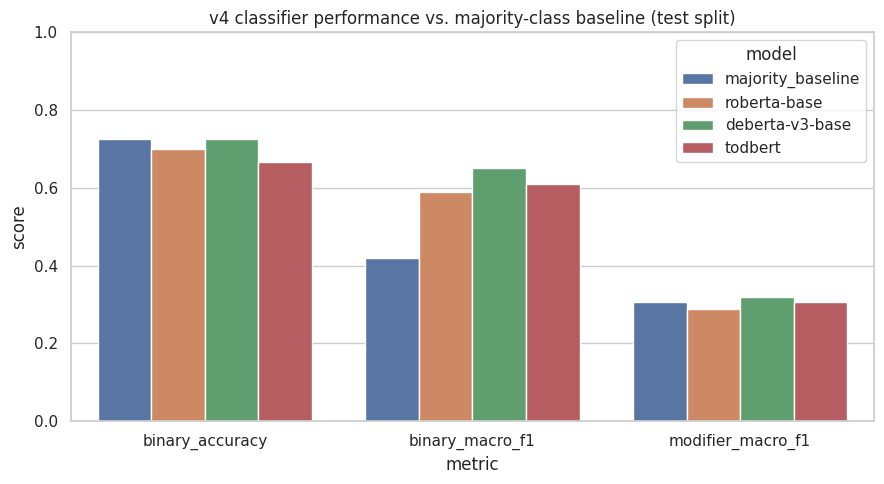

In [16]:
plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["binary_accuracy", "binary_macro_f1", "modifier_macro_f1"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("v4 classifier performance vs. majority-class baseline (test split)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"classifier_comparison_bar_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10b. Confusion matrices — binary_label, per encoder

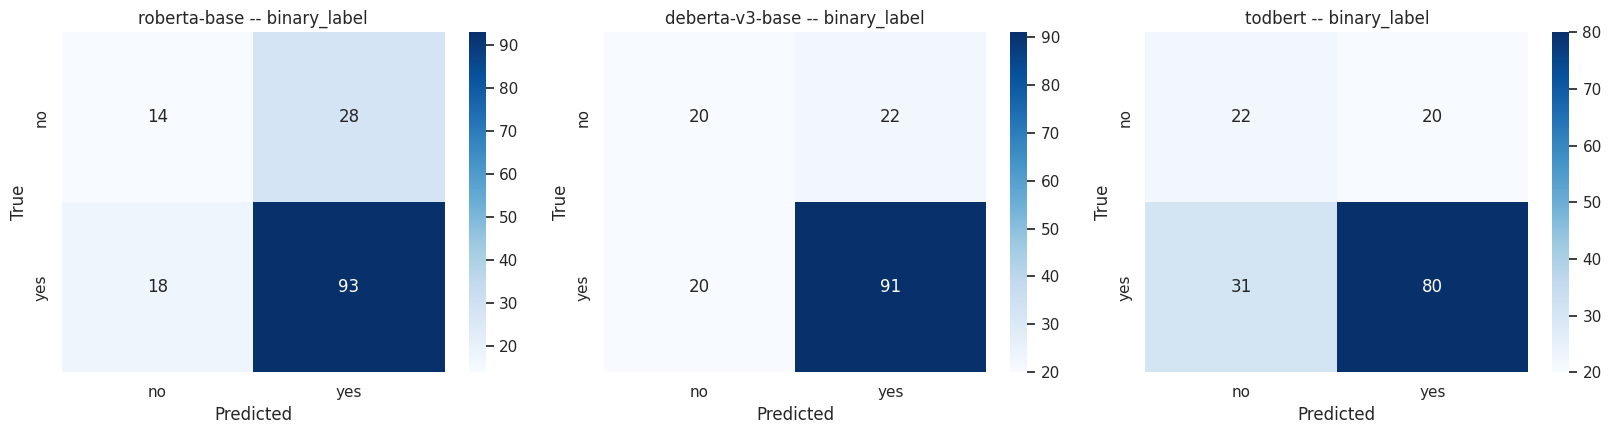

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                           labels=list(range(len(CONFIG["binary_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["binary_classes"], yticklabels=CONFIG["binary_classes"], ax=ax)
    ax.set_title(f"{name} -- binary_label")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_binary_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10c. Confusion matrices — modifier, per encoder

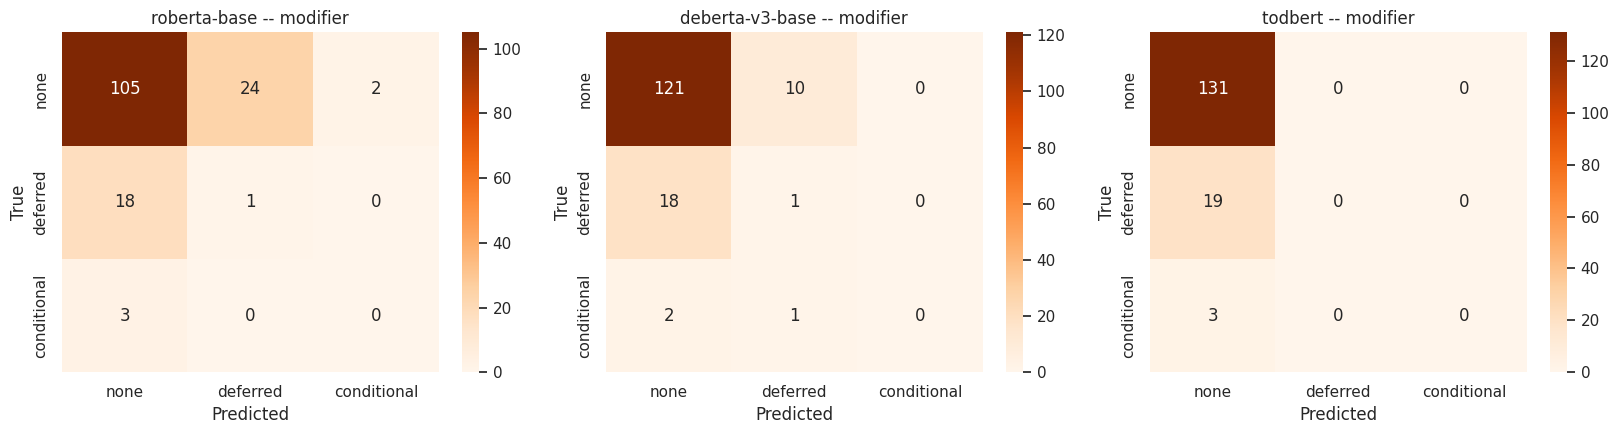

In [18]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                           labels=list(range(len(CONFIG["modifier_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=CONFIG["modifier_classes"], yticklabels=CONFIG["modifier_classes"], ax=ax)
    ax.set_title(f"{name} -- modifier")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"confusion_matrix_modifier_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

### 10d. Training curves — val F1 per epoch, per encoder

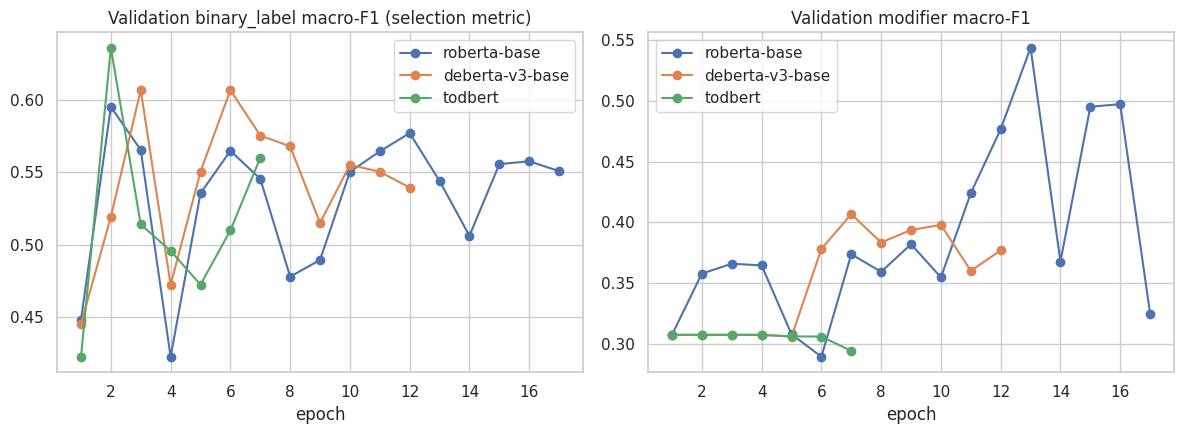

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in results.items():
    hist = pd.DataFrame(r["history"])
    axes[0].plot(hist["epoch"], hist["val_binary_macro_f1"], marker="o", label=name)
    axes[1].plot(hist["epoch"], hist["val_modifier_macro_f1"], marker="o", label=name)
axes[0].set_title("Validation binary_label macro-F1 (selection metric)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation modifier macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], f"training_curves_{CONFIG['run_tag']}.png"), dpi=150)
plt.show()

## 10e. Classification reports (full precision/recall/F1 per class)

In [20]:
for name, r in results.items():
    _sep = "=" * 70
    print(f"\n{_sep}\n{name} -- binary_label classification report\n{_sep}")
    print(classification_report(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                                 target_names=CONFIG["binary_classes"], zero_division=0))
    print(f"{name} -- modifier classification report")
    print(classification_report(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                                 target_names=CONFIG["modifier_classes"], zero_division=0))


roberta-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.44      0.33      0.38        42
         yes       0.77      0.84      0.80       111

    accuracy                           0.70       153
   macro avg       0.60      0.59      0.59       153
weighted avg       0.68      0.70      0.69       153

roberta-base -- modifier classification report
              precision    recall  f1-score   support

        none       0.83      0.80      0.82       131
    deferred       0.04      0.05      0.05        19
 conditional       0.00      0.00      0.00         3

    accuracy                           0.69       153
   macro avg       0.29      0.28      0.29       153
weighted avg       0.72      0.69      0.71       153


deberta-v3-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.50      0.48      0.49        42
         yes       0.81      

## 11. Summary

v7 changes vs. `capstone-v5-augfix.ipynb` (model, loss, and training loop
byte-for-byte unchanged):

| Change | Where | Why |
|---|---|---|
| Connective paraphrase EDA op (`_CONNECTIVE_SYNONYMS`) | augmentation | v3-v5's `PROTECTED_WORDS` correctly protects conditional/deferred signal words from corruption, but as a side effect the model never saw that vocabulary phrased any other way — every augmented copy repeats the source row's exact wording for the words that matter most |
| Back-translation (README idea #4, per-turn, marker-safe) | augmentation | All of `conditional`'s 63 v5 copies (and most of `deferred`'s 141) trace back to ~13 / ~68 real source dialogues, perturbed only at the word level — genuinely different sentence structure was the missing diversity source |
| Same total row counts as v5 (just re-sourced) | augmentation | Isolates this comparison to augmentation *quality*, not quantity |
| Defensive EDA fallback if back-translation fails | augmentation | This is the user's last planned Kaggle run for this line of work — a model-download or generation failure degrades gracefully instead of losing the run |

**What prompted this fork**: v4/v5's actual cached Kaggle outputs
(`ran-nb/ran-v4.ipynb`, `ran-nb/ran-v5.ipynb`) show `conditional` F1 = 0.00
across all six model runs, and `deferred` F1 mostly in the 0.00-0.18
range with v5 not consistently beating v4. See the intro cell for the
full comparison table and the reasoning that led here.

**Still true**: `conditional` has only 13 real source dialogues total —
no augmentation strategy manufactures new labeled information, it only
changes how well the model can generalize from what exists. With a
test-set support of 3 for `conditional`, treat any change in that number
as a weak signal on its own; `deferred` (support=19) is the more
reliable read on whether this augmentation upgrade helped. If this run
still doesn't move `conditional`, the durable fix documented since v3 —
more labeled `conditional` examples — remains the real answer.